In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Folder with your daily CSVs
folder_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/settel_price 2/settel_price/2023/MON_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/backtest    "  # 🔁 Change this

# List CSV files
csv_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])

all_data = []

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    try:
        df = pd.read_csv(file_path)

        # Check column presence
        if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
            print(f"Skipping {file}: missing required columns")
            continue

        # Check if portfolio_value is all 0 or NaN
        if df['portfolio_value'].fillna(0).eq(0).all():
            print(f"Skipping {file}: all portfolio_value entries are 0 or NaN")
            continue

        # Use only relevant columns
        df = df[['timestamp', 'portfolio_value']]
        df['timestamp'] = pd.to_datetime(df['timestamp'])

        all_data.append(df)

    except Exception as e:
        print(f"Error processing {file}: {e}")
        continue

# Combine all valid data
if not all_data:
    raise ValueError("No valid data with portfolio values found.")

equity_df = pd.concat(all_data).sort_values(by='timestamp')

# Plot equity curve
plt.figure(figsize=(14, 6))
plt.plot(equity_df['timestamp'], equity_df['portfolio_value'], label='Equity Curve', color='blue')
plt.xlabel('Time')
plt.ylabel('Portfolio Value')
plt.title('Equity Curve Over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


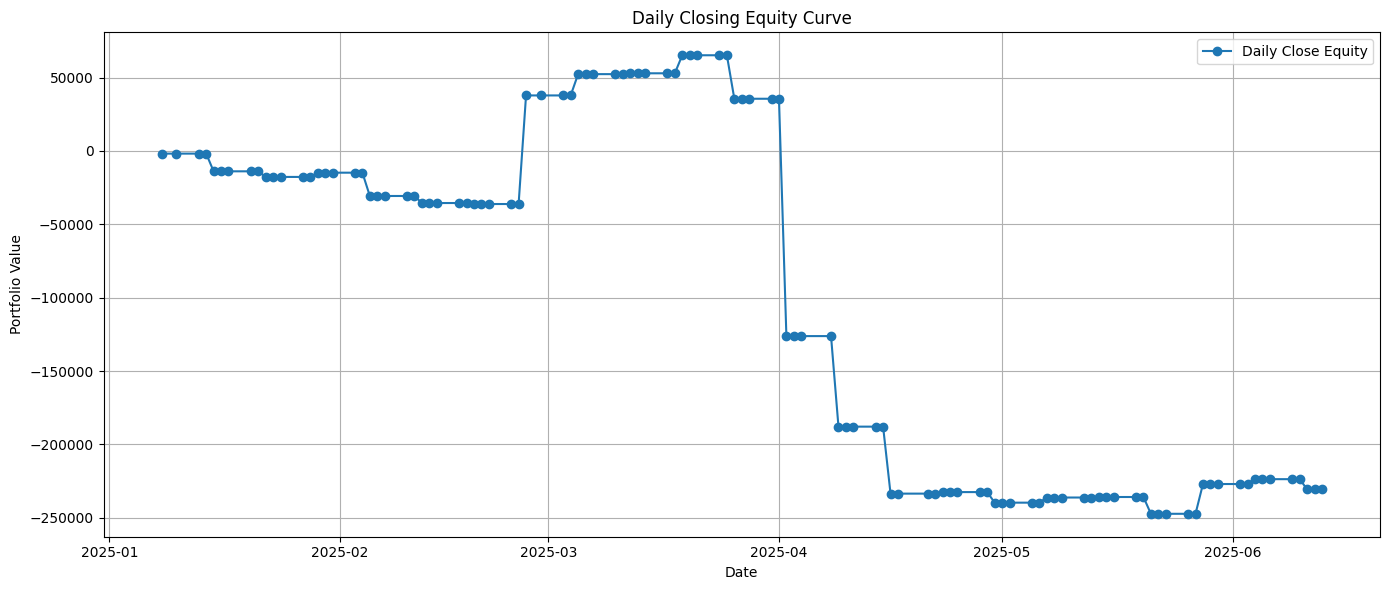

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Folder containing the CSV files
folder_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/without_holidays/THUSPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"

# List CSV files and sort by date in filename (e.g., 20230402.csv)
csv_files = sorted(
    [f for f in os.listdir(folder_path) if f.endswith('.csv')],
    key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
)

daily_data = []
skipped_files = []

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    try:
        df = pd.read_csv(file_path)

        if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
            skipped_files.append(file)
            continue

        # Skip if all values are 0 or NaN
        if df['portfolio_value'].fillna(0).eq(0).all():
            skipped_files.append(file)
            continue

        # Get last row (end of day)
        last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]]
        last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
        daily_data.append(last_row)

    except Exception as e:
        print(f"Error in {file}: {e}")
        skipped_files.append(file)
        continue

# Combine all daily close values
equity_df = pd.concat(daily_data).sort_values(by='date')
equity_df.to_csv("/home/dell/Desktop/debug/THU.csv")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(equity_df['date'], equity_df['portfolio_value'], marker='o', label='Daily Close Equity')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.title('Daily Closing Equity Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



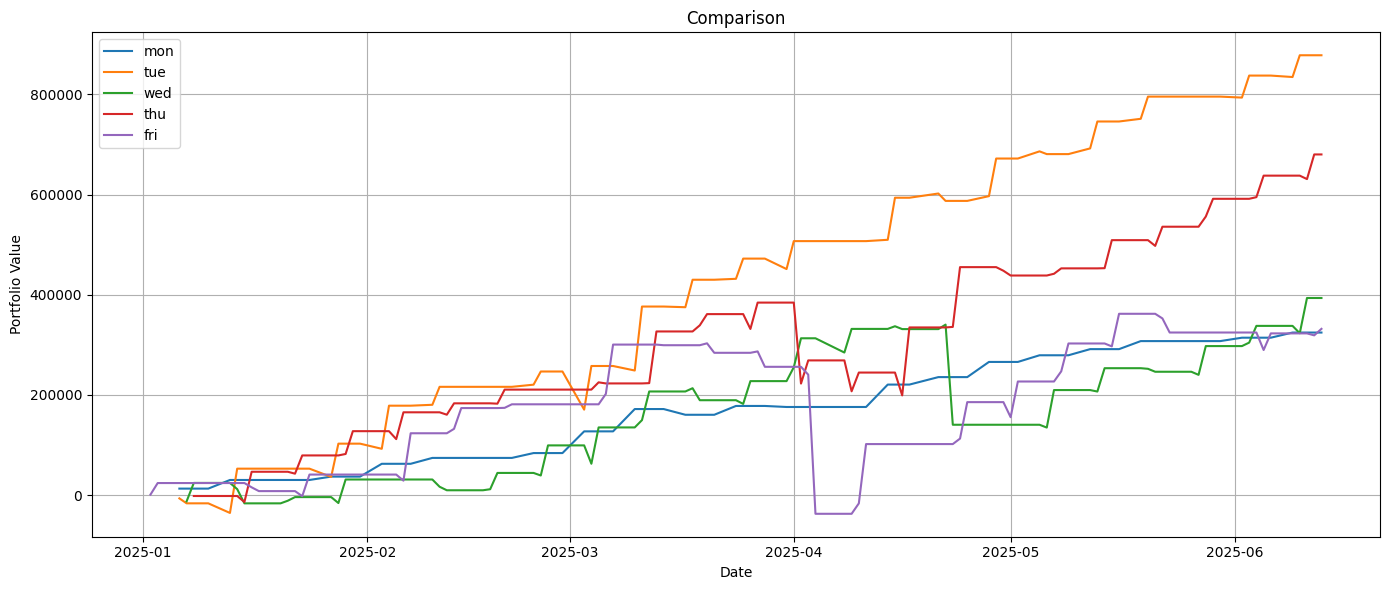

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]]
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Folders for the two strategies
folder_path_1 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/delta_threshold/MON__SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_2 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/delta_threshold/TUE__SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_3 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/delta_threshold/WED__SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_4 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/delta_threshold/THU__SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_5 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/delta_threshold/FRI__SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"


# Extract daily closing values
equity1 = extract_daily_close(folder_path_1).rename(columns={'portfolio_value': 'strategy1'})
equity2 = extract_daily_close(folder_path_2).rename(columns={'portfolio_value': 'strategy2'})
equity3 = extract_daily_close(folder_path_3).rename(columns={'portfolio_value': 'strategy3'})
equity4 = extract_daily_close(folder_path_4).rename(columns={'portfolio_value': 'strategy4'})
equity5 = extract_daily_close(folder_path_5).rename(columns={'portfolio_value': 'strategy5'})

# Merge on date
equity_combined = pd.merge(equity1, equity2, on='date', how='outer').sort_values(by='date')
equity_combined = pd.merge(equity_combined, equity3, on='date', how='outer').sort_values(by='date')
equity_combined = pd.merge(equity_combined, equity4, on='date', how='outer').sort_values(by='date')
equity_combined = pd.merge(equity_combined, equity5, on='date', how='outer').sort_values(by='date')



# Plot raw portfolio values
plt.figure(figsize=(14, 6))
plt.plot(equity_combined['date'], equity_combined['strategy1'], label='mon')
plt.plot(equity_combined['date'], equity_combined['strategy2'], label='tue')
plt.plot(equity_combined['date'], equity_combined['strategy3'], label='wed')
plt.plot(equity_combined['date'], equity_combined['strategy4'], label='thu')
plt.plot(equity_combined['date'], equity_combined['strategy5'], label='fri')

plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.title('Comparison')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]]
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

In [ ]:
folder_path_1 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/MONSPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"


In [4]:
equity1 = extract_daily_close(folder_path_1).rename(columns={'portfolio_value': 'strategy1'})
equity1

,date,strategy1
781,2025-01-06,12931.220
781,2025-01-07,12931.220
781,2025-01-08,12931.220
781,2025-01-10,12931.220
781,2025-01-13,30172.964
781,2025-01-14,30172.964
781,2025-01-15,30172.964
781,2025-01-16,30172.964
781,2025-01-17,30172.964
531,2025-01-20,22888.301


In [2]:
import pandas as pd


In [3]:
df = pd.read_csv("/home/dell/Desktop/HFT-Options-EIS-Global-preprocess_databento/data/databento_preprocessed_data/final/2025/With_futures/SPXW_20250120_Intraday_Preprocessed.csv")

/tmp/ipykernel_12928/2370388143.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/dell/Desktop/HFT-Options-EIS-Global-preprocess_databento/data/databento_preprocessed_data/final/2025/With_futures/SPXW_20250120_Intraday_Preprocessed.csv")


In [45]:
df = pd.read_csv("/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2024/MON/SPXW_20240116_Intraday_Preprocessed.csv")

In [4]:
start_time = pd.to_datetime('2025-01-20 11:58')
end_time = pd.to_datetime('2025-01-20 13:20')

df["Date Time"] = pd.to_datetime(df["Date Time"])
# Step 3: Filter rows between these timestamps
filtered_df = df[(df['Date Time'] >= start_time) & (df['Date Time'] <= end_time)]

In [5]:
filtered_df.to_csv("/home/dell/Desktop/debug/2024012-.csv")

In [32]:
df = pd.read_csv("/home/dell/Desktop/HFT-Options-EIS-Global-preprocess_databento/data/to_process/2025/options/20250120.csv")

In [35]:
start_time = pd.to_datetime('2025-01-20 12:58')
end_time = pd.to_datetime('2025-01-20 16:20')

df["Date_Time"] = pd.to_datetime(df["Date_Time"])
# Step 3: Filter rows between these timestamps
filtered_df = df[(df['Date_Time'] >= start_time) & (df['Date_Time'] <= end_time)]

In [36]:
filtered_df.to_csv("/home/dell/Desktop/debug/20250120_eis_data.csv")

#friday

In [13]:
import os
from glob import glob

In [26]:
import pandas as pd
from glob import glob

folder = "/home/dell/Desktop/FRI_NEW/Spot/"

file_paths = glob(folder + "*.csv")

for file in file_paths:
    df = pd.read_csv(file)

    # Convert to proper boolean in case it's stored as string
    df['Spot_Missing'] = df['Spot_Missing'].astype(bool)

    # Drop rows where Spot_Missing is not False
    df = df[df['Spot_Missing'] == False]

    # Save back
    df.to_csv(file, index=False)


In [27]:
df

,Date Time,Spot,Spot_Missing,Prev_Spot
0,2022-10-11 00:00:00,3606.50,False,3606.75
2,2022-10-11 00:01:00,3607.25,False,3606.50
4,2022-10-11 00:02:00,3606.50,False,3607.25
6,2022-10-11 00:03:00,3607.75,False,3606.50
8,2022-10-11 00:04:00,3607.00,False,3607.75
...,...,...,...,...
2750,2022-10-11 23:55:00,3606.25,False,3605.25
2752,2022-10-11 23:56:00,3606.50,False,3606.25
2754,2022-10-11 23:57:00,3605.75,False,3606.50
2756,2022-10-11 23:58:00,3604.50,False,3605.75


In [1]:
import os
from datetime import datetime

# List of holiday dates to delete
delete_dates = [
    "2025-01-01 00:00:00", "2025-01-09 00:00:00", "2025-01-20 00:00:00",
    "2025-02-17 00:00:00", "2025-04-18 00:00:00", "2025-05-26 00:00:00",
    "2025-06-19 00:00:00", "2025-07-04 00:00:00", "2025-09-01 00:00:00",
    "2025-11-27 00:00:00", "2025-12-25 00:00:00"
]

#temp = ["20250228", "20250303", "20250313", "20250314", "20250317", "20250327", "20250331", "20250430", "20250530","20250131","20250319"]
# Convert dates to 'YYYYMMDD' format
delete_dates_formatted = set([
    datetime.strptime(d, "%Y-%m-%d %H:%M:%S").strftime("%Y%m%d") for d in delete_dates
])

#delete_dates_formatted.update(temp)
print(delete_dates_formatted)
# Folder path
folder_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_with_missing_data_without_holiday/"

# Delete only matching .csv files
for filename in os.listdir(folder_path):
    if not filename.endswith(".csv"):
        continue  # Skip non-csv files

    parts = filename.split('_')
    if len(parts) < 2:
        continue  # Skip if filename doesn't have expected format

    file_date = parts[1]
    if file_date in delete_dates_formatted:
        file_path = os.path.join(folder_path, filename)
        try:
            os.remove(file_path)
            print(f"Deleted: {file_path}")
        except Exception as e:
            print(f"Failed to delete {file_path}: {e}")


{'20251127', '20250217', '20250901', '20250109', '20250101', '20251225', '20250704', '20250526', '20250418', '20250120', '20250619'}
Deleted: /media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_with_missing_data_without_holiday/SPXW_20250526_20250527_Intraday_Preprocessed.csv
Deleted: /media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_with_missing_data_without_holiday/SPXW_20250109_20250129_Intraday_Preprocessed.csv
Deleted: /media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_with_missing_data_without_holiday/SPXW_20250217_20250221_Intraday_Preprocessed.csv
Deleted: /media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_with_missing_data_without_holiday/SPXW_20250120_20250224_Intraday_Preprocessed.csv
Deleted: /media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_with_missing_data_without_holiday/SPXW_20250217_20250620_Intraday_Preprocessed.csv
Deleted: /media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_with_missing_data_wi

#generating weekday files

In [53]:
from datetime import date, timedelta

def get_thursdays_until_june_13(year):
    current_date = date(year, 1, 1)
    end_date = date(year, 6, 13)

    # Move to the first Thursday
    while current_date.weekday() != 2:
        current_date += timedelta(days=1)

    # Collect Thursdays until June 13 (inclusive)
    formatted_thursdays = []
    while current_date <= end_date:
        formatted_thursdays.append(current_date.strftime("%Y-%m-%d"))
        current_date += timedelta(days=7)

    return formatted_thursdays

# Example usage
thursday_strings = get_thursdays_until_june_13(2025)
for ts in thursday_strings:
    print(ts)


2025-01-01
2025-01-08
2025-01-15
2025-01-22
2025-01-29
2025-02-05
2025-02-12
2025-02-19
2025-02-26
2025-03-05
2025-03-12
2025-03-19
2025-03-26
2025-04-02
2025-04-09
2025-04-16
2025-04-23
2025-04-30
2025-05-07
2025-05-14
2025-05-21
2025-05-28
2025-06-04
2025-06-11


In [54]:
import json
file = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/2025_WED/meta_data.json"
# Load the original JSON file
keep_dates = thursday_strings
monthly = ["2025-03-21","2025-06-20"]
keep_dates.extend(monthly)
with open(file, "r") as f:
    data = json.load(f)

# Define the list of dates you want to KEEP
data["Expiry_dates"] = [date for date in data["Expiry_dates"] if date in keep_dates]

# Filter unwind_dates: keep only keys that are in keep_dates
data["Unwind_dates"] = {
    k: v for k, v in data["Unwind_dates"].items() if v in keep_dates
}

# Save the filtered JSON to a new file
with open(file, "w") as f:
    json.dump(data, f)


In [55]:
keep_dates

['2025-01-01',
 '2025-01-08',
 '2025-01-15',
 '2025-01-22',
 '2025-01-29',
 '2025-02-05',
 '2025-02-12',
 '2025-02-19',
 '2025-02-26',
 '2025-03-05',
 '2025-03-12',
 '2025-03-19',
 '2025-03-26',
 '2025-04-02',
 '2025-04-09',
 '2025-04-16',
 '2025-04-23',
 '2025-04-30',
 '2025-05-07',
 '2025-05-14',
 '2025-05-21',
 '2025-05-28',
 '2025-06-04',
 '2025-06-11',
 '2025-03-21',
 '2025-06-20']

In [48]:
data["Unwind_dates"]

{'2025-01-03': '2025-01-03',
 '2025-01-10': '2025-01-10',
 '2025-01-17': '2025-01-17',
 '2025-01-24': '2025-01-24',
 '2025-01-31': '2025-01-31',
 '2025-02-07': '2025-02-07',
 '2025-02-14': '2025-02-14',
 '2025-02-21': '2025-02-21',
 '2025-02-28': '2025-02-28',
 '2025-03-07': '2025-03-07',
 '2025-03-14': '2025-03-14',
 '2025-03-21': '2025-03-21',
 '2025-03-28': '2025-03-28',
 '2025-04-04': '2025-04-04',
 '2025-04-07': '2025-04-04',
 '2025-04-11': '2025-04-11',
 '2025-04-25': '2025-04-25',
 '2025-05-02': '2025-05-02',
 '2025-05-09': '2025-05-09',
 '2025-05-16': '2025-05-16',
 '2025-05-23': '2025-05-23',
 '2025-05-30': '2025-05-30',
 '2025-06-06': '2025-06-06',
 '2025-06-13': '2025-06-13',
 '2025-06-16': '2025-06-13',
 '2025-06-17': '2025-06-13',
 '2025-06-18': '2025-06-13',
 '2025-06-20': '2025-06-13',
 '2025-06-23': '2025-06-13',
 '2025-06-24': '2025-06-13',
 '2025-06-25': '2025-06-13',
 '2025-06-26': '2025-06-13',
 '2025-06-27': '2025-06-13',
 '2025-07-01': '2025-06-13',
 '2025-07-02':

In [3]:
import pandas as pd
import glob
import os

# Define folder path
folder = '/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/data/SPX/futures_eis/futures_with_bidask'

# Find all CSV files in the folder
csv_files = glob.glob(os.path.join(folder, "*.csv"))

# Read and concatenate all CSVs
df_list = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)

# Ensure there's a datetime column to sort by
if 'datetime' not in combined_df.columns:
    combined_df['datetime'] = pd.to_datetime(combined_df['Date'].astype(str) + ' ' + combined_df['Time'].astype(str))

# Sort by datetime
combined_df = combined_df.sort_values('datetime').reset_index(drop=True)

# (Optional) Drop duplicate rows or filter by date if needed
# combined_df = combined_df.drop_duplicates()

print("Concatenation complete. Shape:", combined_df.shape)


Concatenation complete. Shape: (1005910, 14)


In [5]:
combined_df["bid_ask_spread"]= combined_df["AskPrice"]- combined_df["BidPrice"]

In [6]:
combined_df

,Date,Time,Symbol,PrevSeq,BidQty,BidPrice,AskPrice,AskQty,LTP,TTQ,TTV,datetime,MidPrice,minute,bid_ask_spread
0,20250601,17:00:00.040128480,ESM5,4203,NaN,5897.25,5897.75,NaN,5898.75,254.0,1.498282e+06,2025-06-01 17:00:00.040128480,5897.500,2025-06-01 17:00:00,0.50
1,20250601,17:00:00.044711295,ESU5,4206,NaN,5949.00,5952.00,NaN,5952.25,1.0,5.952250e+03,2025-06-01 17:00:00.044711295,5950.500,2025-06-01 17:00:00,3.00
2,20250601,17:00:01.001170012,ESM5,5234,1.0,5897.25,5897.75,1.0,5897.75,363.0,2.141084e+06,2025-06-01 17:00:01.001170012,5897.500,2025-06-01 17:00:00,0.50
3,20250601,17:00:01.009914319,ESU5,5243,1.0,5949.00,5952.00,1.0,5952.25,1.0,5.952250e+03,2025-06-01 17:00:01.009914319,5950.500,2025-06-01 17:00:00,3.00
4,20250601,17:00:02.024957105,ESM5,5747,1.0,5898.00,5898.50,1.0,5898.50,448.0,2.642362e+06,2025-06-01 17:00:02.024957105,5898.250,2025-06-01 17:00:00,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005905,20250613,15:59:58.150678598,ESU5,60428679,2.0,6030.25,6030.75,2.0,6030.00,324442.0,1.959693e+09,2025-06-13 15:59:58.150678598,6030.500,2025-06-13 15:59:00,0.50
1005906,20250613,15:59:59.078555425,ESM5,60428772,8.0,5978.25,5978.50,1.0,5978.25,1465822.0,8.779593e+09,2025-06-13 15:59:59.078555425,5978.375,2025-06-13 15:59:00,0.25
1005907,20250613,15:59:59.094648667,ESU5,60428788,3.0,6030.25,6030.50,1.0,6030.00,324442.0,1.959693e+09,2025-06-13 15:59:59.094648667,6030.375,2025-06-13 15:59:00,0.25
1005908,20250613,16:00:00.100058308,ESM5,60428997,4.0,5978.00,5978.50,2.0,5978.25,1465824.0,8.779605e+09,2025-06-13 16:00:00.100058308,5978.250,2025-06-13 16:00:00,0.50


In [12]:
# Group by symbol and floored minute, keep the first instance
df = combined_df.groupby(['Symbol', 'minute'], as_index=False).first()


In [13]:
df

,Symbol,minute,Date,Time,PrevSeq,BidQty,BidPrice,AskPrice,AskQty,LTP,TTQ,TTV,datetime,MidPrice,bid_ask_spread
0,ESH6,2025-06-11 10:25:00,20250611,10:25:10.593542853,22458352,NaN,6187.75,6230.75,NaN,6221.50,1.0,6221.5,2025-06-11 10:25:10.593542853,6209.250,43.00
1,ESH6,2025-06-11 10:44:00,20250611,10:44:09.437053960,22799192,3.0,6187.75,6230.75,3.0,6221.50,1.0,6221.5,2025-06-11 10:44:09.437053960,6209.250,43.00
2,ESH6,2025-06-11 10:48:00,20250611,10:48:23.536647358,22875512,3.0,6187.75,6230.75,3.0,6221.50,1.0,6221.5,2025-06-11 10:48:23.536647358,6209.250,43.00
3,ESH6,2025-06-11 11:05:00,20250611,11:05:17.407588216,23215639,3.0,6181.50,6224.50,3.0,6221.50,1.0,6221.5,2025-06-11 11:05:17.407588216,6203.000,43.00
4,ESH6,2025-06-11 11:07:00,20250611,11:07:06.669873123,23291408,3.0,6175.25,6218.25,3.0,6221.50,1.0,6221.5,2025-06-11 11:07:06.669873123,6196.750,43.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38179,ESZ5,2025-06-13 15:56:00,20250613,15:56:01.440697709,60410182,5.0,6081.50,6082.75,5.0,6085.25,188.0,1144948.0,2025-06-13 15:56:01.440697709,6082.125,1.25
38180,ESZ5,2025-06-13 15:57:00,20250613,15:57:03.382275546,60413266,5.0,6081.00,6082.00,1.0,6085.25,188.0,1144948.0,2025-06-13 15:57:03.382275546,6081.500,1.00
38181,ESZ5,2025-06-13 15:58:00,20250613,15:58:01.909310978,60417406,5.0,6081.00,6082.25,5.0,6085.25,188.0,1144948.0,2025-06-13 15:58:01.909310978,6081.625,1.25
38182,ESZ5,2025-06-13 15:59:00,20250613,15:59:00.263427524,60425429,5.0,6079.00,6080.25,5.0,6085.25,188.0,1144948.0,2025-06-13 15:59:00.263427524,6079.625,1.25


In [11]:
df_unique["Symbol"].unique()

array(['ESH6', 'ESM5', 'ESM6', 'ESU5', 'ESZ5'], dtype=object)

In [14]:
symbol = 'ESM5'
symbol_df = df[df['Symbol'] == symbol].sort_values('datetime')

In [15]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=symbol_df['datetime'],
    y=symbol_df['bid_ask_spread'],
    mode='lines+markers',
    name=f'{symbol} Bid-Ask Spread',
    line=dict(color='blue')
))

fig.update_layout(
    title=f'Bid-Ask Spread Over Time for {symbol}',
    xaxis_title='Datetime',
    yaxis_title='Bid-Ask Spread',
    template='plotly_white',
    height=500,
    width=900
)

fig.show()


In [19]:
import pandas as pd
import plotly.graph_objects as go

# Filter and sort by symbol
symbol = 'ESM5'
symbol_df = df[df['Symbol'] == symbol].copy()
symbol_df = symbol_df.sort_values('datetime')

# Use 'minute' column to get daily date
symbol_df['minute']= pd.to_datetime(symbol_df['minute'])

symbol_df['date'] = symbol_df['minute'].dt.floor('D')

# Daily average bid-ask spread
daily_spread = symbol_df.groupby('date')['bid_ask_spread'].mean().reset_index()

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=daily_spread['date'],
    y=daily_spread['bid_ask_spread'],
    mode='lines+markers',
    name=f'{symbol} Daily Mean Bid-Ask Spread',
    line=dict(color='purple')
))

fig.update_layout(
    title=f'Daily Mean Bid-Ask Spread for {symbol}',
    xaxis_title='Date',
    yaxis_title='Bid-Ask Spread (Mean)',
    template='plotly_white',
    height=500,
    width=900
)

fig.show()


In [19]:
import os
import pandas as pd
import glob 

In [20]:
folder_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2025/all_day_hedging/THU_5SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/blotter"
file_list = glob.glob(os.path.join(folder_path,"*.csv"))

df_list = [pd.read_csv(file) for file in file_list]
df = pd.concat(df_list, ignore_index=True)



In [21]:
df

,timestamp,trade_id,packet_id,component_trade_id,trade_component,instrument_id,instrument_id_key,position,price,trade_sub_type,instrument_object,exchange_fee,transaction_fee
0,2025-05-15 00:02:00,1,1,1,hedge_component,20250620,SPXW_0_ES_20250620,-5.0,5898.00,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
1,2025-05-15 01:26:00,2,2,2,hedge_component,20250620,SPXW_0_ES_20250620,-4.0,5892.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
2,2025-05-15 01:48:00,3,3,3,hedge_component,20250620,SPXW_0_ES_20250620,-2.0,5886.50,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
3,2025-05-15 02:14:00,4,4,4,hedge_component,20250620,SPXW_0_ES_20250620,-1.0,5892.50,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
4,2025-05-15 03:12:00,5,5,5,hedge_component,20250620,SPXW_0_ES_20250620,-3.0,5887.50,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5992,2025-01-23 12:52:00,15,15,15,hedge_component,20250321,SPXW_0_ES_20250321,1.0,6131.00,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5993,2025-01-23 13:12:00,16,16,16,hedge_component,20250321,SPXW_0_ES_20250321,-1.0,6134.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5994,2025-01-23 13:20:00,17,17,17,hedge_component,20250321,SPXW_0_ES_20250321,1.0,6137.50,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5995,2025-01-23 15:00:00,18,18,18,hedge_component,20250321,SPXW_0_ES_20250321,3.0,6134.50,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0


In [22]:
df["timestamp"]=pd.to_datetime(df["timestamp"])

In [23]:
df = df.sort_values("timestamp").reset_index(drop=True)
df

,timestamp,trade_id,packet_id,component_trade_id,trade_component,instrument_id,instrument_id_key,position,price,trade_sub_type,instrument_object,exchange_fee,transaction_fee
0,2025-01-08 09:30:00,1,1,1,day_of_week_delta_condor_component,808,SPXW_5975_CE_20250109,-50.0,2.925,trade,"{'detailed': True, 'instrument_type': 'option'...",0,0
1,2025-01-08 09:30:00,2,1,1,day_of_week_delta_condor_component,861,SPXW_5895_PE_20250109,-50.0,6.250,trade,"{'detailed': True, 'instrument_type': 'option'...",0,0
2,2025-01-08 09:35:00,3,2,2,day_of_week_delta_condor_component,809,SPXW_5980_CE_20250109,-50.0,3.500,trade,"{'detailed': True, 'instrument_type': 'option'...",0,0
3,2025-01-08 09:35:00,4,2,2,day_of_week_delta_condor_component,863,SPXW_5905_PE_20250109,-50.0,5.800,trade,"{'detailed': True, 'instrument_type': 'option'...",0,0
4,2025-01-08 09:40:00,5,3,3,day_of_week_delta_condor_component,808,SPXW_5975_CE_20250109,-50.0,3.875,trade,"{'detailed': True, 'instrument_type': 'option'...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5992,2025-06-12 13:10:00,44,44,44,hedge_component,20250620,SPXW_0_ES_20250620,1.0,6046.250,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5993,2025-06-12 13:28:00,45,45,45,hedge_component,20250620,SPXW_0_ES_20250620,-1.0,6042.000,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5994,2025-06-12 13:36:00,46,46,46,hedge_component,20250620,SPXW_0_ES_20250620,1.0,6047.250,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5995,2025-06-12 14:22:00,47,47,47,hedge_component,20250620,SPXW_0_ES_20250620,1.0,6044.250,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0


In [24]:
df_hedge = df[df["trade_component"]=="hedge_component"]
df_hedge

,timestamp,trade_id,packet_id,component_trade_id,trade_component,instrument_id,instrument_id_key,position,price,trade_sub_type,instrument_object,exchange_fee,transaction_fee
20,2025-01-08 10:16:00,21,11,1,hedge_component,20250321,SPXW_0_ES_20250321,-1.0,5931.75,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
23,2025-01-08 10:20:00,24,13,2,hedge_component,20250321,SPXW_0_ES_20250321,1.0,5926.75,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
30,2025-01-08 10:36:00,31,17,3,hedge_component,20250321,SPXW_0_ES_20250321,1.0,5944.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
32,2025-01-08 10:40:00,34,19,4,hedge_component,20250321,SPXW_0_ES_20250321,1.0,5940.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
38,2025-01-08 10:52:00,39,22,5,hedge_component,20250321,SPXW_0_ES_20250321,1.0,5950.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5992,2025-06-12 13:10:00,44,44,44,hedge_component,20250620,SPXW_0_ES_20250620,1.0,6046.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5993,2025-06-12 13:28:00,45,45,45,hedge_component,20250620,SPXW_0_ES_20250620,-1.0,6042.00,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5994,2025-06-12 13:36:00,46,46,46,hedge_component,20250620,SPXW_0_ES_20250620,1.0,6047.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0
5995,2025-06-12 14:22:00,47,47,47,hedge_component,20250620,SPXW_0_ES_20250620,1.0,6044.25,hedge,"{'detailed': True, 'instrument_type': 'future'...",0,0


In [25]:
hedges = df_hedge['position'].sum()
abs_hedges = df_hedge['position'].abs().sum()

In [26]:
hedges

99.0

In [27]:
abs_hedges

6565.0

In [18]:
df['position'].unique()

array([-50.,  -1.,   1.,  -2.,   2.,   3.,  -4.,   4.,   7.,  -3.,   5.,
        15., -17.,  -5.,   6.,  -8., -11.,  -7.,  -6.,  11.,   9., -10.,
        -9., -12.,  13., -13., -54.,   8.,  10.,  20.,  27., -19.,  17.,
       -14., -27., -15., -20., -23.,  14.,  53.,  16., -25.,  12., -76.,
        23., -21., -63.,  47., -22.])

fm3 + 5

In [33]:
total_hedges = 0
total_abs_hedges = 0
days = ["MON","TUE","WED","THU","FRI"]
for day in days:
    folder_path = f"/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2025/all_day_hedging/{day}_5SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/blotter"

    file_list = glob.glob(os.path.join(folder_path,"*.csv"))

    df_list = [pd.read_csv(file) for file in file_list]
    df = pd.concat(df_list, ignore_index=True)
    df["timestamp"]=pd.to_datetime(df["timestamp"])

    df = df.sort_values("timestamp").reset_index(drop=True)
    df_hedge = df[df["trade_component"]=="hedge_component"]
    hedges = df_hedge['position'].sum()
    abs_hedges = df_hedge['position'].abs().sum()
    total_hedges+=hedges
    total_abs_hedges+=abs_hedges
print(total_hedges)
print(total_abs_hedges)


380.0
24982.0


In [34]:
total_abs_hedges*50*0.27/2

168628.5

fm3

In [31]:
total_hedges = 0
total_abs_hedges = 0
days = ["MON","TUE","WED","THU","FRI"]
for day in days:
    folder_path = f"/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/price_threshold_chartpack/{day}_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/blotter/"
    file_list = glob.glob(os.path.join(folder_path,"*.csv"))

    df_list = [pd.read_csv(file) for file in file_list]
    df = pd.concat(df_list, ignore_index=True)
    df["timestamp"]=pd.to_datetime(df["timestamp"])

    df = df.sort_values("timestamp").reset_index(drop=True)
    df_hedge = df[df["trade_component"]=="hedge_component"]
    hedges = df_hedge['position'].sum()
    abs_hedges = df_hedge['position'].abs().sum()
    total_hedges+=hedges
    total_abs_hedges+=abs_hedges
print(total_hedges)
print(total_abs_hedges)

397.0
19351.0


In [32]:
total_abs_hedges*50*0.27/2

130619.25000000001

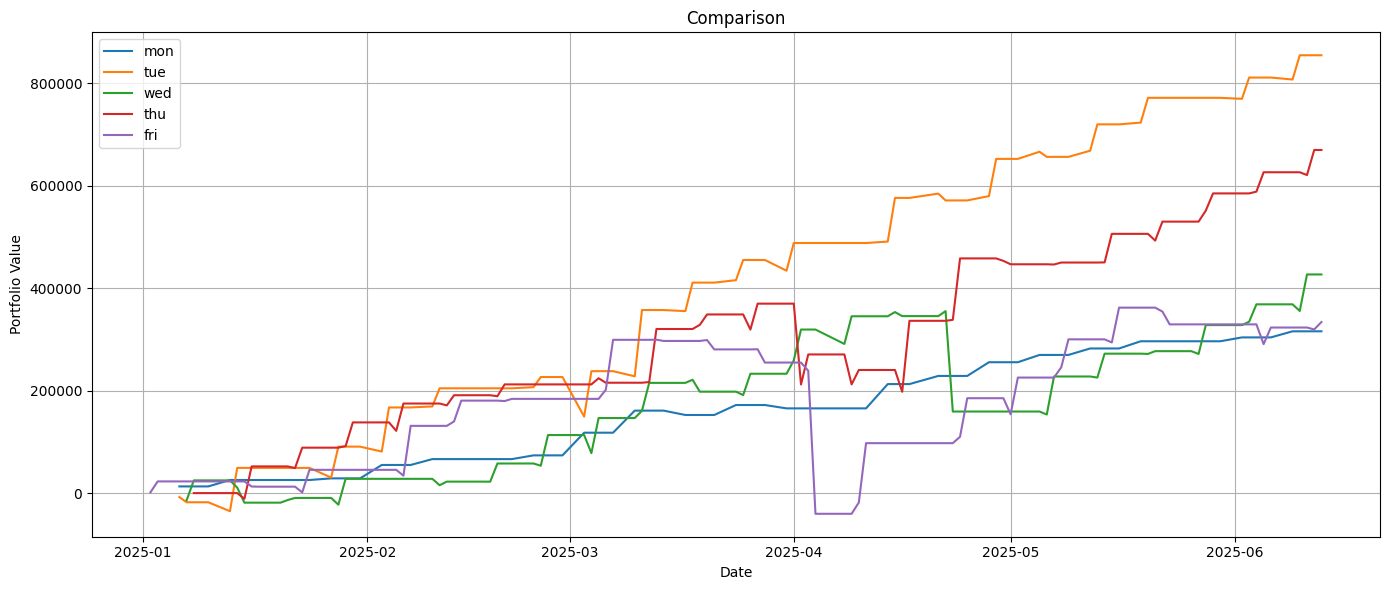

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]]
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Folders for the two strategies
folder_path_1 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/price_threshold_chartpack/MON_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_2 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/price_threshold_chartpack/TUE_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_3 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/price_threshold_chartpack/WED_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_4 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/price_threshold_chartpack/THU_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
folder_path_5 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/price_threshold_chartpack/FRI_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"


# Extract daily closing values
equity1 = extract_daily_close(folder_path_1).rename(columns={'portfolio_value': 'strategy1'})
equity2 = extract_daily_close(folder_path_2).rename(columns={'portfolio_value': 'strategy2'})
equity3 = extract_daily_close(folder_path_3).rename(columns={'portfolio_value': 'strategy3'})
equity4 = extract_daily_close(folder_path_4).rename(columns={'portfolio_value': 'strategy4'})
equity5 = extract_daily_close(folder_path_5).rename(columns={'portfolio_value': 'strategy5'})

# Merge on date
equity_combined = pd.merge(equity1, equity2, on='date', how='outer').sort_values(by='date')
equity_combined = pd.merge(equity_combined, equity3, on='date', how='outer').sort_values(by='date')
equity_combined = pd.merge(equity_combined, equity4, on='date', how='outer').sort_values(by='date')
equity_combined = pd.merge(equity_combined, equity5, on='date', how='outer').sort_values(by='date')



# Plot raw portfolio values
plt.figure(figsize=(14, 6))
plt.plot(equity_combined['date'], equity_combined['strategy1'], label='mon')
plt.plot(equity_combined['date'], equity_combined['strategy2'], label='tue')
plt.plot(equity_combined['date'], equity_combined['strategy3'], label='wed')
plt.plot(equity_combined['date'], equity_combined['strategy4'], label='thu')
plt.plot(equity_combined['date'], equity_combined['strategy5'], label='fri')

plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.title('Comparison')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Base path for strategy folders
base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2025/trial_verification/price_threshold_chartpack"
days = ["MON", "TUE", "WED", "THU", "FRI"]
strategy_data = []

# Extract and rename strategy data for each weekday
for day in days:
    folder_path = os.path.join(base_path, f"{day}_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
    df = extract_daily_close(folder_path)
    if not df.empty:
        df = df.rename(columns={"portfolio_value": day})
        strategy_data.append(df)

# Merge all strategies on the 'date' column
from functools import reduce
equity_combined = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), strategy_data)
equity_combined = equity_combined.sort_values(by='date')

# Plot using Plotly
fig = go.Figure()

for day in days:
    if day in equity_combined.columns:
        fig.add_trace(go.Scatter(x=equity_combined['date'], y=equity_combined[day], mode='lines', name=day.lower()))

fig.update_layout(
    title='Portfolio Value Comparison by Day of Week',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Base path for strategy folders
base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2025/all_day_hedging"
days = ["MON", "TUE", "WED", "THU", "FRI"]
strategy_data = []

# Extract and rename strategy data for each weekday
for day in days:
    folder_path = os.path.join(base_path, f"{day}_5SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
    df = extract_daily_close(folder_path)
    if not df.empty:
        df = df.rename(columns={"portfolio_value": day})
        strategy_data.append(df)

# Merge all strategies on the 'date' column
from functools import reduce
equity_combined = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), strategy_data)
equity_combined = equity_combined.sort_values(by='date')

# Plot using Plotly
fig = go.Figure()

for day in days:
    if day in equity_combined.columns:
        fig.add_trace(go.Scatter(x=equity_combined['date'], y=equity_combined[day], mode='lines', name=day.lower()))

fig.update_layout(
    title='Portfolio Value Comparison by Day of Week 2025 fm 3 + 5',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [41]:
#2024 comparison

In [48]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Base path for strategy folders
base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2024"
days = ["MON", "TUE", "WED", "THU", "FRI"]
strategy_data = []

# Extract and rename strategy data for each weekday
for day in days:
    folder_path = os.path.join(base_path, f"{day}_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
    df = extract_daily_close(folder_path)
    if not df.empty:
        df = df.rename(columns={"portfolio_value": day})
        strategy_data.append(df)

# Merge all strategies on the 'date' column
from functools import reduce
equity_combined = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), strategy_data)
equity_combined = equity_combined.sort_values(by='date')

# Plot using Plotly
fig = go.Figure()

for day in days:
    if day in equity_combined.columns:
        fig.add_trace(go.Scatter(x=equity_combined['date'], y=equity_combined[day], mode='lines', name=day.lower()))

fig.update_layout(
    title='Portfolio Value Comparison by Day of Week 2024 fm 3',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [45]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Base path for strategy folders
base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2024/all_day_hedging"
days = ["MON", "TUE", "WED", "THU", "FRI"]
strategy_data = []

# Extract and rename strategy data for each weekday
for day in days:
    folder_path = os.path.join(base_path, f"{day}_5SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
    df = extract_daily_close(folder_path)
    if not df.empty:
        df = df.rename(columns={"portfolio_value": day})
        strategy_data.append(df)

# Merge all strategies on the 'date' column
from functools import reduce
equity_combined = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), strategy_data)
equity_combined = equity_combined.sort_values(by='date')

# Plot using Plotly
fig = go.Figure()

for day in days:
    if day in equity_combined.columns:
        fig.add_trace(go.Scatter(x=equity_combined['date'], y=equity_combined[day], mode='lines', name=day.lower()))

fig.update_layout(
    title='Portfolio Value Comparison by Day of Week 2024 fm 3 + 5',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [58]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Base path for strategy folders
base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2024/all_day_hedging"
days = ["MON", "TUE", "WED", "THU", "FRI"]
strategy_data = []

# Extract and rename strategy data for each weekday
for day in days:
    folder_path = os.path.join(base_path, f"{day}_10SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
    df = extract_daily_close(folder_path)
    if not df.empty:
        df = df.rename(columns={"portfolio_value": day})
        strategy_data.append(df)

# Merge all strategies on the 'date' column
from functools import reduce
equity_combined = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), strategy_data)
equity_combined = equity_combined.sort_values(by='date')

# Plot using Plotly
fig = go.Figure()

for day in days:
    if day in equity_combined.columns:
        fig.add_trace(go.Scatter(x=equity_combined['date'], y=equity_combined[day], mode='lines', name=day.lower()))

fig.update_layout(
    title='Portfolio Value Comparison by Day of Week 2024 fm 3 + ',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [59]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Base path for strategy folders
base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2024/all_day_hedging"
#days = ["MON", "TUE", "WED", "THU", "FRI"]
day_of_week = "MON"
variants = [5,7.5,10]
strategy_data = []

# Extract and rename strategy data for each weekday
for variant in variants:
    folder_path = os.path.join(base_path, f"{day_of_week}_{variant}SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
    df = extract_daily_close(folder_path)
    if not df.empty:
        df = df.rename(columns={"portfolio_value": variant})
        strategy_data.append(df)

# Merge all strategies on the 'date' column
from functools import reduce
equity_combined = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), strategy_data)
equity_combined = equity_combined.sort_values(by='date')

# Plot using Plotly
fig = go.Figure()

for day in variants:
    if day in equity_combined.columns:
        fig.add_trace(go.Scatter(x=equity_combined['date'], y=equity_combined[day], mode='lines', name=day))

fig.update_layout(
    title=f'Portfolio Value Comparison by Day of Week 2024 {day_of_week} fm 3 ',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [57]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# Base path for strategy folders
base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2024/all_day_hedging"
#days = ["MON", "TUE", "WED", "THU", "FRI"]
day_of_week = "WED"
variants = [5,7.5,10]
strategy_data = []

# Extract and rename strategy data for each weekday
for variant in variants:
    folder_path = os.path.join(base_path, f"{day_of_week}_{variant}SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
    df = extract_daily_close(folder_path)
    if not df.empty:
        df = df.rename(columns={"portfolio_value": variant})
        strategy_data.append(df)

# Merge all strategies on the 'date' column
from functools import reduce
equity_combined = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), strategy_data)
equity_combined = equity_combined.sort_values(by='date')

# Plot using Plotly
fig = go.Figure()

for day in variants:
    if day in equity_combined.columns:
        fig.add_trace(go.Scatter(x=equity_combined['date'], y=equity_combined[day], mode='lines', name=day))

fig.update_layout(
    title=f'Portfolio Value Comparison by Day of Week 2024 {day_of_week} fm 3 ',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [12]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# ----------- Manually define and extract the two strategies ------------

base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/trial/2022/fm_3_baseline"
day_of_week = "THU"

# Strategy 1: 5 SPXW
folder_path_5 = os.path.join(base_path, f"{day_of_week}_5SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
df_5 = extract_daily_close(folder_path_5)
df_5 = df_5.rename(columns={"portfolio_value": "5 SPXW"})

# Strategy 2: 10 SPXW
folder_path_10 = f"/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/all_years/2022/{day_of_week}_3_SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store"
df_10 = extract_daily_close(folder_path_10)
df_10 = df_10.rename(columns={"portfolio_value": "base SPXW"})

# ------------- Merge -------------
combined_df = pd.merge(df_5, df_10, on='date', how='outer').sort_values(by='date')

# ------------- Plot -------------
fig = go.Figure()

fig.add_trace(go.Scatter(x=combined_df['date'], y=combined_df["5 SPXW"], mode='lines', name="5 SPXW"))
fig.add_trace(go.Scatter(x=combined_df['date'], y=combined_df["base SPXW"], mode='lines', name="base SPXW"))

fig.update_layout(
    title=f'Comparison of 5 vs 10 SPXW Portfolio Values on {day_of_week}, 2022',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

def extract_daily_close(folder_path):
    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.csv')],
        key=lambda x: pd.to_datetime(x.replace('.csv', ''), format='%Y%m%d')
    )

    daily_data = []

    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        
        try:
            df = pd.read_csv(file_path)

            if 'timestamp' not in df.columns or 'portfolio_value' not in df.columns:
                continue

            if df['portfolio_value'].fillna(0).eq(0).all():
                continue

            last_row = df[['timestamp', 'portfolio_value']].iloc[[-1]].copy()
            last_row['date'] = pd.to_datetime(file.replace('.csv', ''), format='%Y%m%d')
            daily_data.append(last_row)

        except Exception as e:
            continue

    if not daily_data:
        return pd.DataFrame()

    result_df = pd.concat(daily_data)[['date', 'portfolio_value']]
    return result_df

# ----------- Manually define and extract the two strategies ------------

base_path = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/asia hedging/2025/all_day_hedging"
day_of_week = "WED"

# Strategy 1: 5 SPXW
folder_path_5 = os.path.join(base_path, f"{day_of_week}_{5}SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store")
df_5 = extract_daily_close(folder_path_5)
df_5 = df_5.rename(columns={"portfolio_value": "5 SPXW"})

# Strategy 2: 10 SPXW
folder_path_10 = "/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/outputs/trial/2025/fm_3_baseline/WED_5SPXW_DAY_OF_WEEK_DELTA_CONDOR_STRATEGY/consolidated_store/"
df_10 = extract_daily_close(folder_path_10)
df_10 = df_10.rename(columns={"portfolio_value": "base SPXW"})

# ------------- Merge -------------
combined_df = pd.merge(df_5, df_10, on='date', how='outer').sort_values(by='date')

# ------------- Plot -------------
fig = go.Figure()

fig.add_trace(go.Scatter(x=combined_df['date'], y=combined_df["5 SPXW"], mode='lines', name="5 SPXW"))
fig.add_trace(go.Scatter(x=combined_df['date'], y=combined_df["base SPXW"], mode='lines', name="base SPXW"))

fig.update_layout(
    title=f'Comparison of 5 vs 10 SPXW Portfolio Values on {day_of_week}, 2022',
    xaxis_title='Date',
    yaxis_title='Portfolio Value',
    template='plotly_white',
    height=600,
    width=1000
)

fig.show()


In [13]:
df = pd.read_csv("/media/dell/548d4dc2-4844-4adb-8b24-7b412b8f3455/0DT_Settelment_Backtest/HFT-Options-EIS-Global/tradelib/underlying/SPX_2020_2024_EOD.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-01-02,3244.669922,3258.139893,3235.530029,3257.850098,3257.850098,3459930000
1,2020-01-03,3226.360107,3246.149902,3222.340088,3234.850098,3234.850098,3484700000
2,2020-01-06,3217.550049,3246.840088,3214.639893,3246.280029,3246.280029,3702460000
3,2020-01-07,3241.860107,3244.909912,3232.429932,3237.179932,3237.179932,3435910000
4,2020-01-08,3238.590088,3267.070068,3236.669922,3253.050049,3253.050049,3726840000


In [15]:
import plotly.graph_objects as go
import pandas as pd
import glob

In [ ]:


years = ["2022","2023","2024"]
df_combined = {}
for year in years:
    folder_path = f"/home/dell/Desktop/data/{year}/FRI_NEW/Spot/"
    file_list = glob.glob(os.path.join(folder_path,"*.csv"))

    df_list = [pd.read_csv(file) for file in file_list]
    df = pd.concat(df_list, ignore_index=True)
    df["Date Time"]=pd.to_datetime(df["Date Time"])

    df = df.sort_values("Date Time").reset_index(drop=True)
    df['Year'] = df['Date Time'].dt.year
    df_combined[year]=df
    
fig = go.Figure()

for year in years:
    fig.add_trace(go.Scatter(
        x=df_combined[year]['Date Time'],
        y=df_combined[year]['Spot'],
        mode='lines',
        name=f'{year} Spot'
    ))

fig.update_layout(
    title='Spot Price Comparison across years',
    xaxis_title='Date Time',
    yaxis_title='Spot Price',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    height=600
)

fig.show()